In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.subplots as sp
import plotly.figure_factory as ff
from plotly import tools
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import os
import gc
from datetime import datetime
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from catboost import CatBoostClassifier
from sklearn import svm
import lightgbm as lgb
from lightgbm import LGBMClassifier
import xgboost as xgb

In [3]:
IS_LOCAL = True

if IS_LOCAL:
    PATH = './data'
else:
    PATH = '/Users/yukunliu/Desktop/Repo/XGBoost/CreditCardFraudDetection/data'

#### read data

In [ ]:
data_df = pd.read_csv(PATH + '/creditcard.csv')
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
data_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
data_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
# check missing values
total = data_df.isnull().sum().sort_values(ascending=False)
percent = (data_df.isnull().sum()/data_df.isnull().count()*100).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent']).transpose()
missing_data.head()

,Time,V16,Amount,V28,V27,V26,V25,V24,V23,V22,...,V10,V9,V8,V7,V6,V5,V4,V3,V2,Class
Total,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


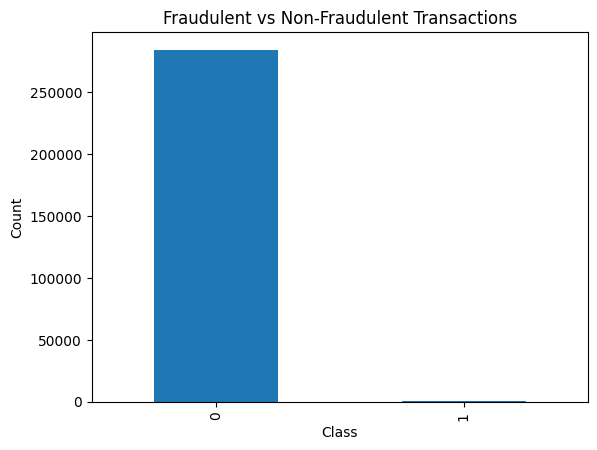

In [9]:
# check data balance
temp = data_df['Class'].value_counts()
temp.plot(kind='bar')
plt.title('Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


### Data Exploration

In [23]:
# transaction over time
class_0 = data_df[data_df['Class'] == 0]['Time']
class_1 = data_df[data_df['Class'] == 1]['Time']

hist_data = [class_0, class_1]
group_labels = ['Non-Fraudulent', 'Fraudulent']

fig = ff.create_distplot(hist_data, group_labels, show_hist=False, show_rug=False)
fig['layout'].update(title='Credit Card Transactions Time Density Plot', xaxis=dict(title='Time [s]'))
fig.show()


In [32]:
# CHANGED: Hour derived locally for EDA only — not stored in data_df (excluded from modeling)
_hour_eda = data_df.assign(Hour=data_df['Time'].apply(lambda x: np.floor(x/3600)))

tmp = _hour_eda.groupby(['Hour', 'Class'])['Amount'].aggregate(['min', 'max', 'count', 'sum', 'mean', 'median', 'var']).reset_index()
df = pd.DataFrame(tmp)
df.columns = ['Hour', 'Class', 'Min', 'Max', 'Transactions', 'Sum', 'Mean', 'Median', 'Var']
df.head()

,Hour,Class,Min,Max,Transactions,Sum,Mean,Median,Var
0,0.0,0,0.0,7712.43,3961,256572.87,64.774772,12.990,45615.821201
1,0.0,1,0.0,529.00,2,529.00,264.500000,264.500,139920.500000
2,1.0,0,0.0,1769.69,2215,145806.76,65.826980,22.820,20053.615770
3,1.0,1,59.0,239.93,2,298.93,149.465000,149.465,16367.832450
4,2.0,0,0.0,4002.88,1555,106989.39,68.803466,17.900,45355.430437


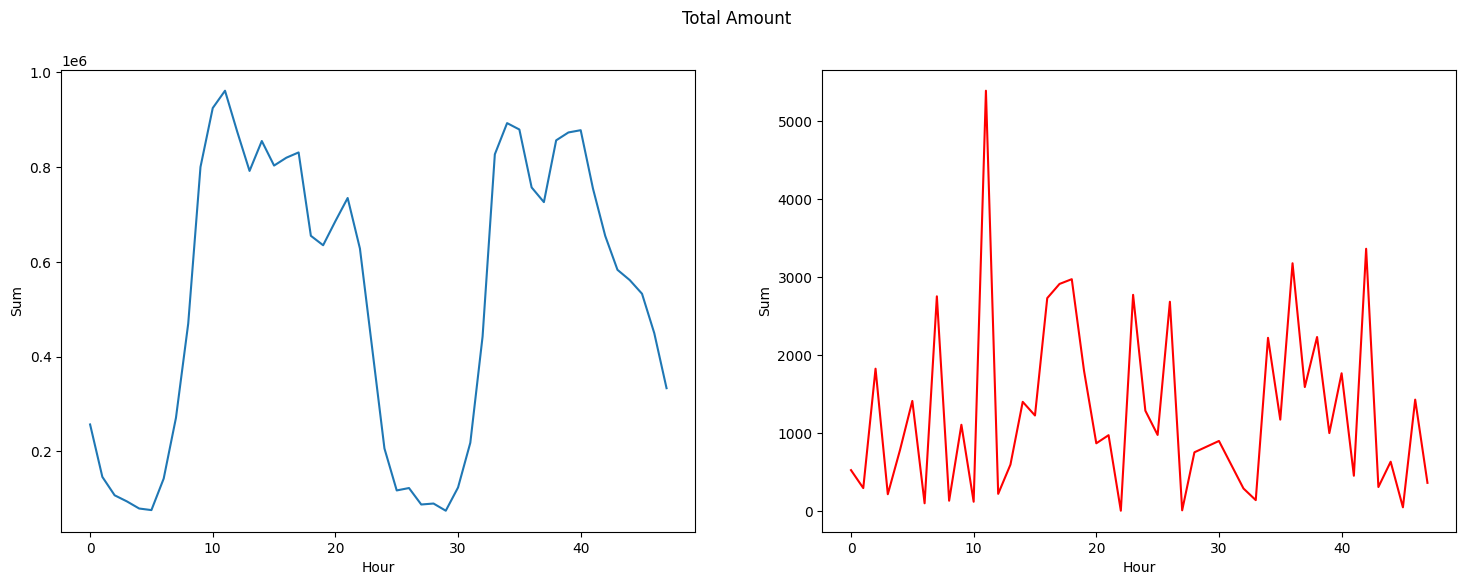

In [33]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Sum", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Sum", data=df.loc[df.Class==1], color="red")
plt.suptitle("Total Amount")
plt.show();

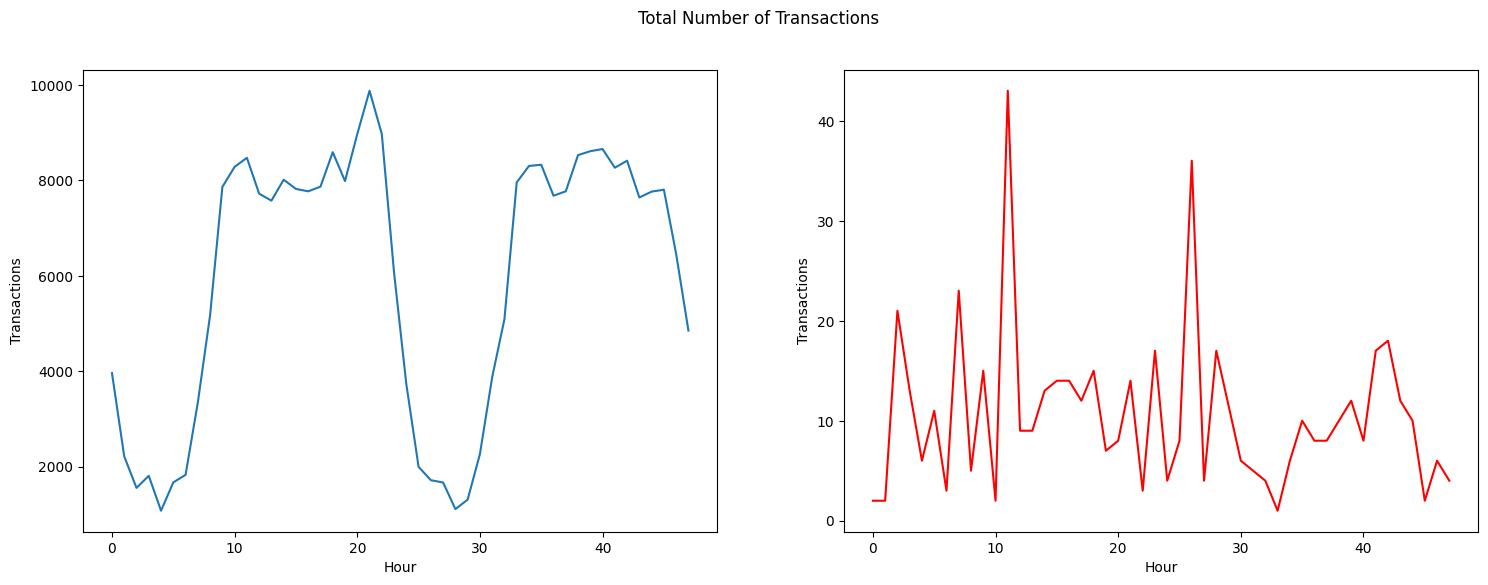

In [34]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Transactions", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Transactions", data=df.loc[df.Class==1], color="red")
plt.suptitle("Total Number of Transactions")
plt.show();

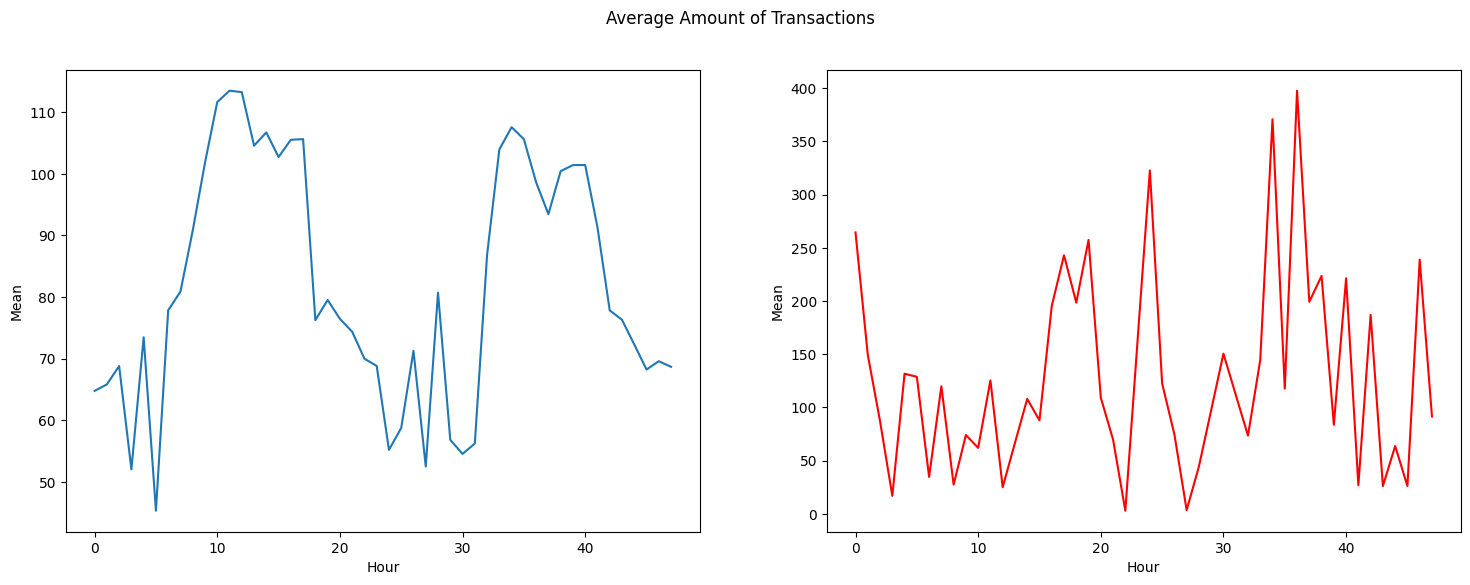

In [35]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Mean", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Mean", data=df.loc[df.Class==1], color="red")
plt.suptitle("Average Amount of Transactions")
plt.show();

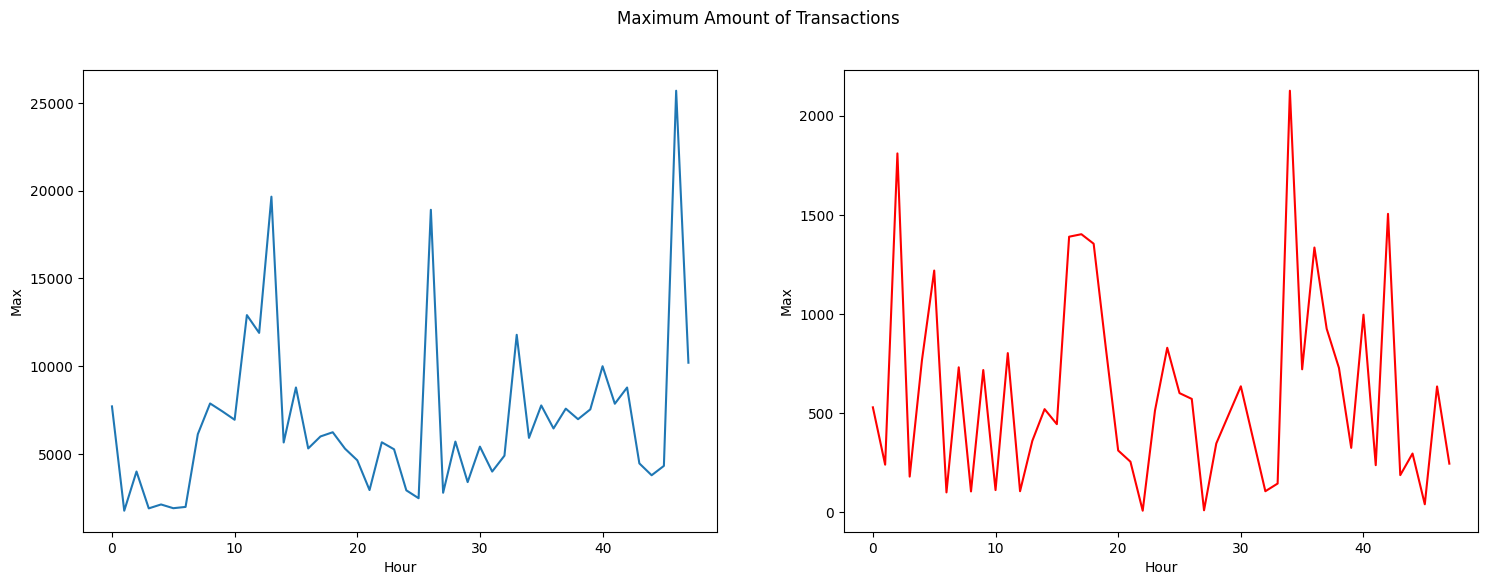

In [36]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Max", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Max", data=df.loc[df.Class==1], color="red")
plt.suptitle("Maximum Amount of Transactions")
plt.show();

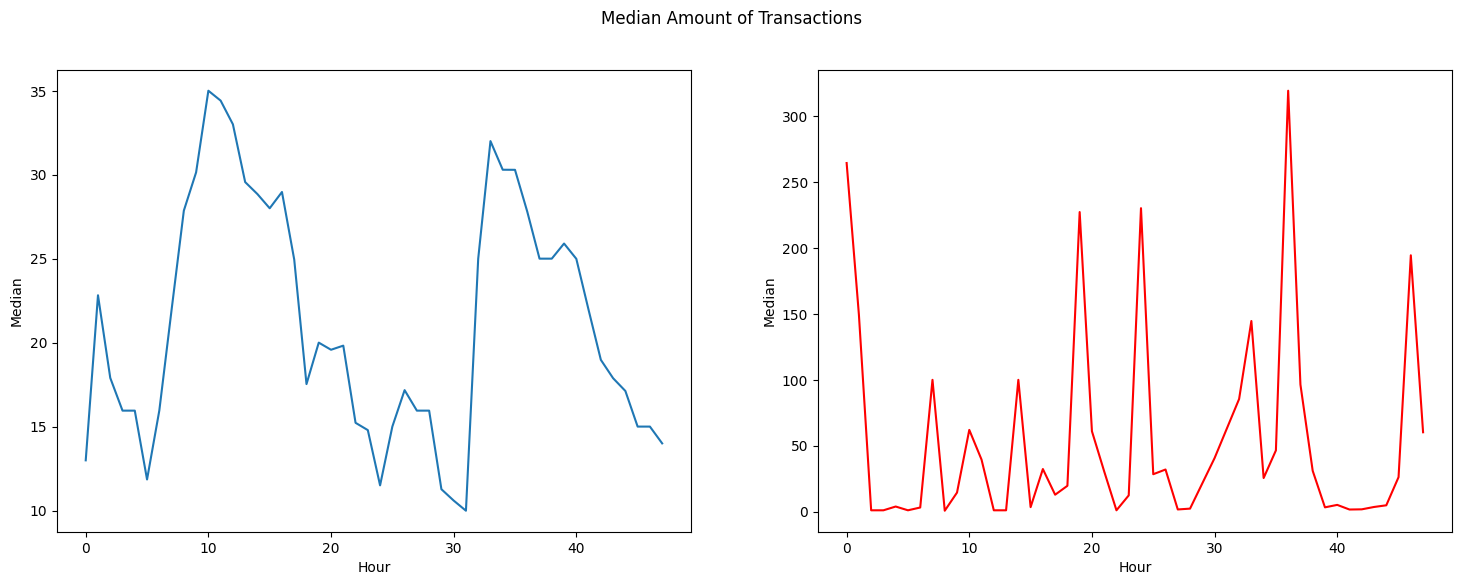

In [37]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Median", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Median", data=df.loc[df.Class==1], color="red")
plt.suptitle("Median Amount of Transactions")
plt.show();


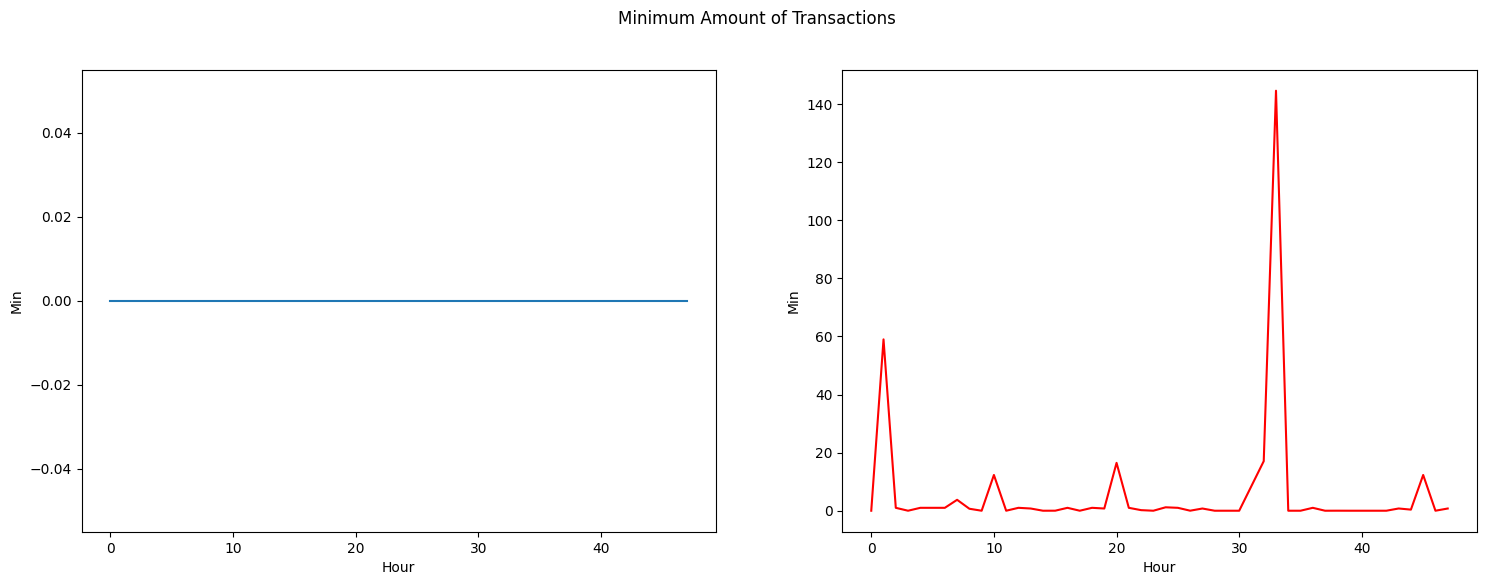

In [38]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Min", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Min", data=df.loc[df.Class==1], color="red")
plt.suptitle("Minimum Amount of Transactions")
plt.show();

### Transaction Amount

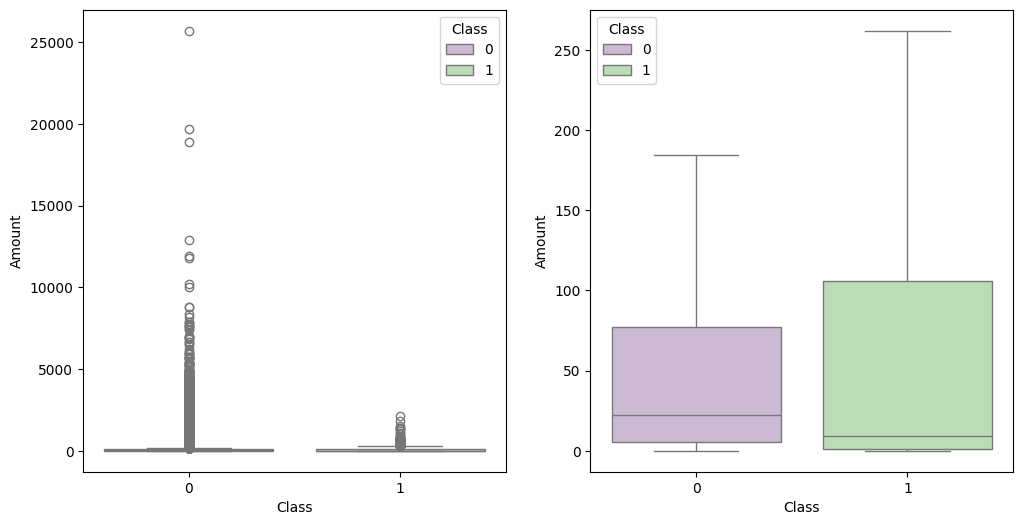

In [39]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))
s = sns.boxplot(ax = ax1, x="Class", y="Amount", hue = "Class", data=data_df, palette="PRGn", showfliers=True)
s = sns.boxplot(ax = ax2, x="Class", y="Amount", hue = "Class", data=data_df, palette="PRGn", showfliers=False)
plt.show();



In [40]:
tmp = data_df[['Class', 'Amount']].copy()
class_0 = tmp.loc[tmp.Class == 0]['Amount']
class_1 = tmp.loc[tmp.Class == 1]['Amount']

class_0.describe()


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [41]:
class_1.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [42]:
# Fradulent transactions against time
fraud = data_df.loc[data_df['Class'] == 1]

trace = go.Scatter(
    x = fraud['Time'],y = fraud['Amount'],
    name="Amount",
     marker=dict(
                color='rgb(238,23,11)',
                line=dict(
                    color='red',
                    width=1),
                opacity=0.5,
            ),
    text= fraud['Amount'],
    mode = "markers"
)
data = [trace]
layout = dict(title = 'Amount of fraudulent transactions',
          xaxis = dict(title = 'Time [s]', showticklabels=True), 
          yaxis = dict(title = 'Amount'),
          hovermode='closest'
         )
fig = dict(data=data, layout=layout)
iplot(fig, filename='fraud-amount')




### Feature Correlation

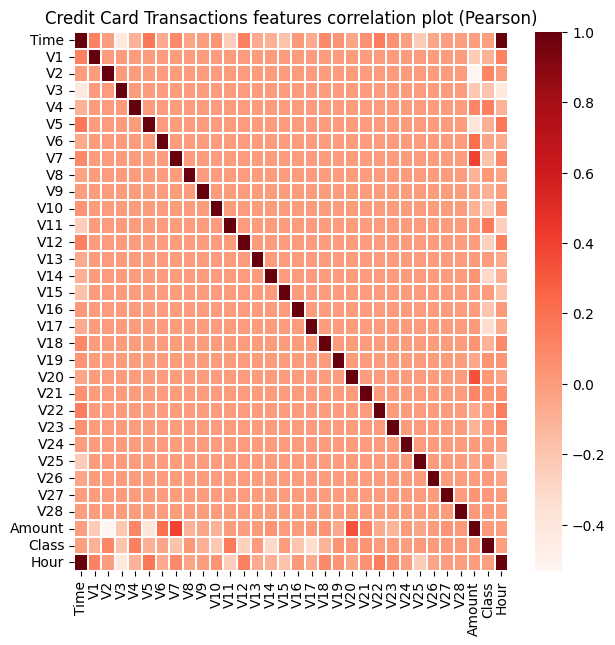

In [44]:
plt.figure(figsize = (7,7))
plt.title('Credit Card Transactions features correlation plot (Pearson)')
corr = data_df.corr()
sns.heatmap(corr,xticklabels=corr.columns,yticklabels=corr.columns,linewidths=.1,cmap="Reds")
plt.show()

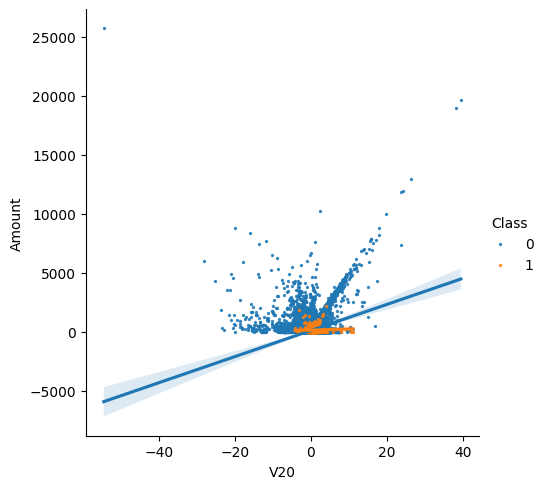

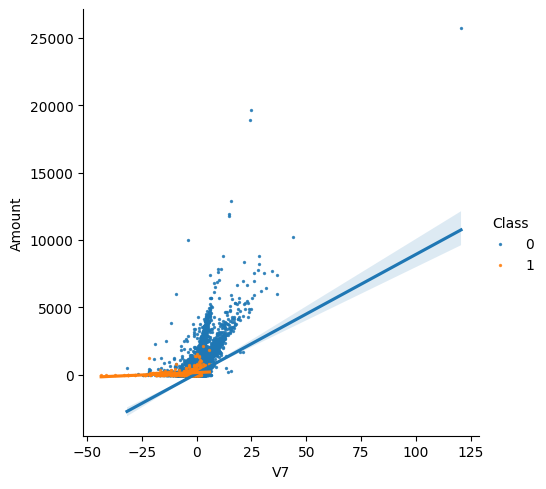

In [ ]:
s = sns.lmplot(x='V20', y='Amount',data=data_df, hue='Class', fit_reg=True, scatter_kws={'s':2})
s = sns.lmplot(x='V7', y='Amount',data=data_df, hue='Class', fit_reg=True, scatter_kws={'s':2})
plt.show()

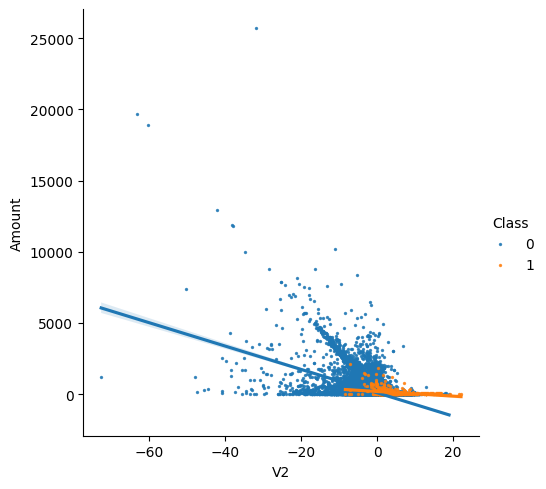

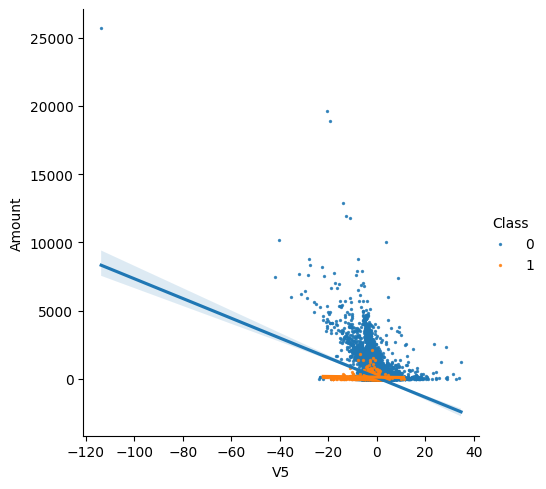

In [46]:
s = sns.lmplot(x='V2', y='Amount',data=data_df, hue='Class', fit_reg=True, scatter_kws={'s':2})
s = sns.lmplot(x='V5', y='Amount',data=data_df, hue='Class', fit_reg=True, scatter_kws={'s':2})
plt.show()

### Feature Density Plot

/var/folders/c_/cz8cmk71741187tt3pk45vdc0000gn/T/ipykernel_17264/2108115793.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(t0[feature], bw_adjust=0.5, label="Class = 0")
/var/folders/c_/cz8cmk71741187tt3pk45vdc0000gn/T/ipykernel_17264/2108115793.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(t1[feature], bw_adjust=0.5, label="Class = 1")


<Figure size 640x480 with 0 Axes>

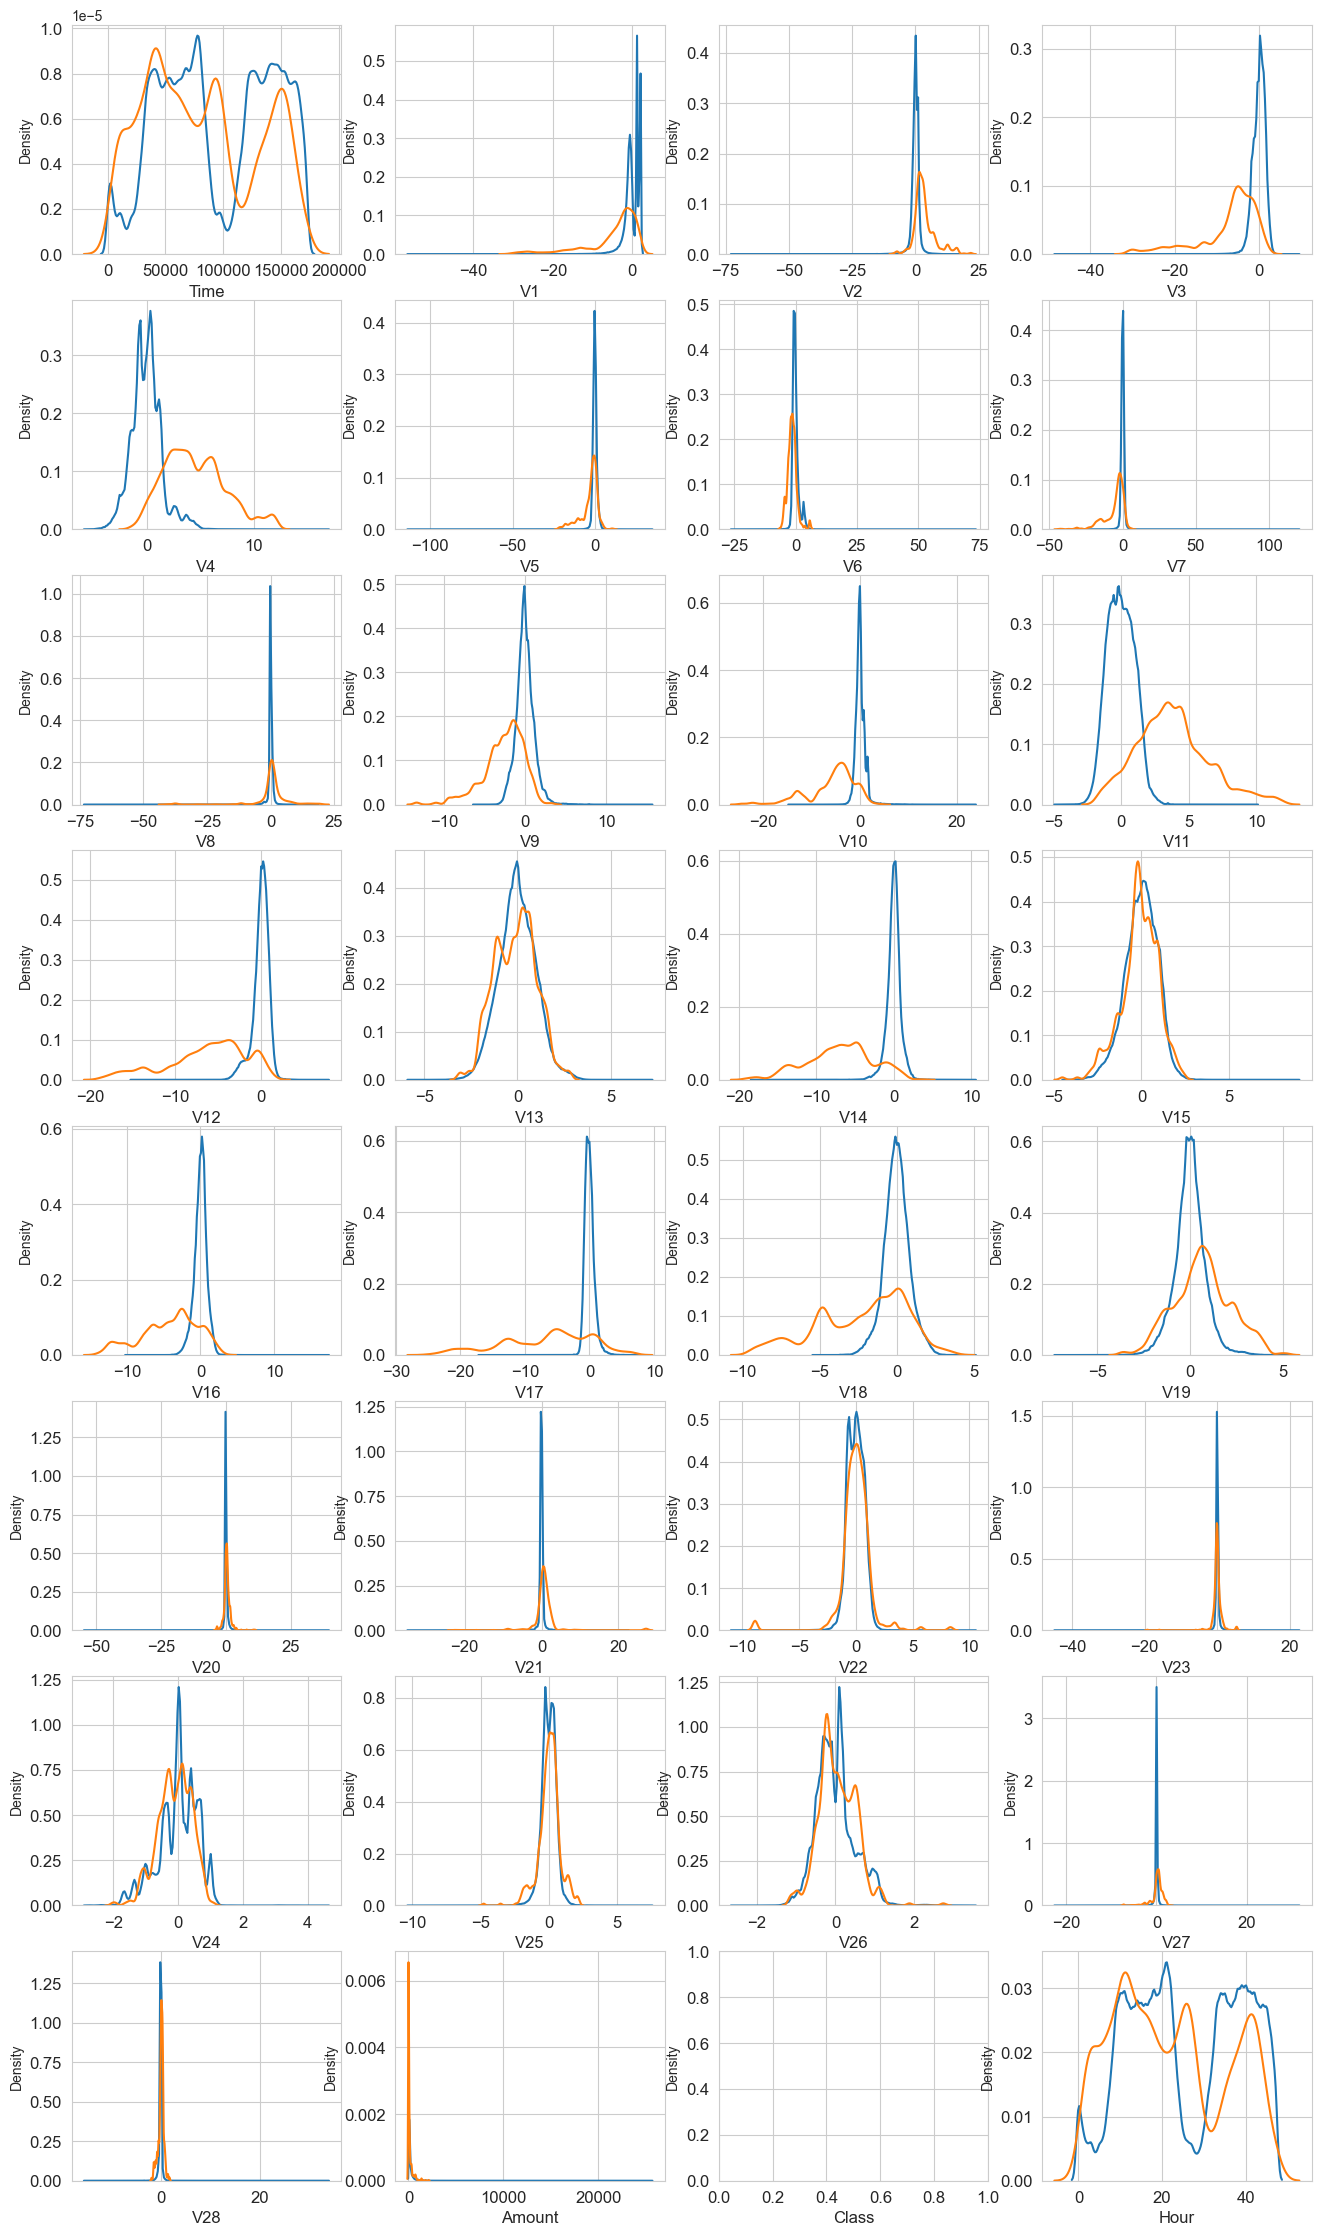

In [48]:
var = data_df.columns.values

i = 0
t0 = data_df.loc[data_df['Class'] == 0]
t1 = data_df.loc[data_df['Class'] == 1]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(8,4,figsize=(16,28))

for feature in var:
    i += 1
    plt.subplot(8,4,i)
    sns.kdeplot(t0[feature], bw_adjust=0.5, label="Class = 0")
    sns.kdeplot(t1[feature], bw_adjust=0.5, label="Class = 1")
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show();

### Evaluation Foundation (Phase 0)

**Objective:** Define how we split data and measure models before training anything.

| Rule | Why |
|---|---|
| Drop duplicate rows before splitting | Prevents the same transaction appearing in both train and test |
| Stratified 60/20/20 split | Keeps ~0.17% fraud rate in every set |
| No `Hour` feature | Derived from `Time`; redundant and excluded from modeling |
| **PR-AUC** as primary metric | Focuses on the rare fraud class |
| ROC-AUC as secondary | Useful for ranking, but can look optimistic when negatives dominate |
| Test set locked | Use validation for tuning; evaluate on test **once** at the end |

In [1]:
# ============================================================
# EVALUATION FOUNDATION (Phase 0) — NEW
# Stratified 60/20/20 split, duplicate removal, metric helpers
# ============================================================

RANDOM_STATE = 42
TARGET = 'Class'

# --- 1. Prepare modeling dataframe: drop duplicates, exclude Hour ---
n_before = len(data_df)
modeling_df = data_df.drop_duplicates().reset_index(drop=True)
n_duplicates_removed = n_before - len(modeling_df)

FEATURES = [
    col for col in modeling_df.columns
    if col not in [TARGET] and col != 'Hour'
]

print(f'Rows before dedup:  {n_before:,}')
print(f'Rows after dedup:   {len(modeling_df):,}')
print(f'Duplicates removed: {n_duplicates_removed:,}')
print(f'Features ({len(FEATURES)}): Time, V1–V28, Amount')

# --- 2. Stratified 60/20/20 split ---
# Step A: 80% train+val / 20% test
train_val_df, test_df = train_test_split(
    modeling_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=modeling_df[TARGET],
    shuffle=True,
)

# Step B: 75% of train+val → train, 25% → val  (0.75 × 0.8 = 0.6, 0.25 × 0.8 = 0.2)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=train_val_df[TARGET],
    shuffle=True,
)


def split_summary(df, name):
    return {
        'set': name,
        'rows': len(df),
        'fraud_cases': int(df[TARGET].sum()),
        'fraud_rate': f"{df[TARGET].mean():.4%}",
    }


split_report = pd.DataFrame([
    split_summary(train_df, 'train'),
    split_summary(val_df, 'validation'),
    split_summary(test_df, 'test'),
    split_summary(modeling_df, 'full (deduped)'),
])
display(split_report)


# --- 3. Metric helpers (always pass probability scores, not hard 0/1 labels) ---
def evaluate_classifier(y_true, y_prob, threshold=0.5, set_name=''):
    """Return a dict of evaluation metrics for a binary classifier."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'set': set_name,
        'pr_auc': average_precision_score(y_true, y_prob),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'threshold': threshold,
    }


def print_evaluation(y_true, y_prob, set_name='validation', threshold=0.5):
    """Print metrics and confusion matrix. Uses probabilities for AUC metrics."""
    m = evaluate_classifier(y_true, y_prob, threshold, set_name)
    print(f"\n=== Evaluation: {set_name} (threshold={threshold}) ===")
    print(f"  PR-AUC (primary):  {m['pr_auc']:.4f}")
    print(f"  ROC-AUC:           {m['roc_auc']:.4f}")
    print(f"  Precision:         {m['precision']:.4f}")
    print(f"  Recall:            {m['recall']:.4f}")
    print(f"  F1:                {m['f1']:.4f}")
    cm = confusion_matrix(y_true, (y_prob >= threshold).astype(int))
    print(f"\n  Confusion matrix [[TN, FP], [FN, TP]]:\n{cm}")
    return m


def metrics_to_df(metrics_list):
    return pd.DataFrame(metrics_list)


# Aliases for downstream modeling cells
target = TARGET
features = FEATURES

print('\nEvaluation foundation ready.')
print('  Primary metric : PR-AUC (average_precision_score)')
print('  Secondary metric: ROC-AUC')
print('  Test set is locked until final evaluation.')

NameError: name 'data_df' is not defined

### Predictive Model

In [49]:
# CHANGED: features and splits come from Evaluation Foundation above — do not redefine here
assert 'Hour' not in features, 'Hour must not be in modeling features'
assert target == 'Class'
print(f'Modeling with {len(features)} features')
print(f'Splits — train: {len(train_df):,} | val: {len(val_df):,} | test: {len(test_df):,}')

In [52]:
# CHANGED: removed old random split — train/val/test are created in Evaluation Foundation (Phase 0)
# Re-splitting here would break reproducibility and risk data leakage.
print('Using stratified splits from Evaluation Foundation:')
print(f'  train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')

### Random Forest

In [53]:
num_jobs = 4
num_estimators = 100
metric = 'gini'

In [64]:
clf = RandomForestClassifier(n_jobs=num_jobs, n_estimators=num_estimators, criterion=metric, verbose=False, class_weight='balanced')

In [65]:
clf.fit(train_df[features], train_df[target].values)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [66]:
preds = clf.predict(val_df[features])

/var/folders/c_/cz8cmk71741187tt3pk45vdc0000gn/T/ipykernel_17264/3333144942.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


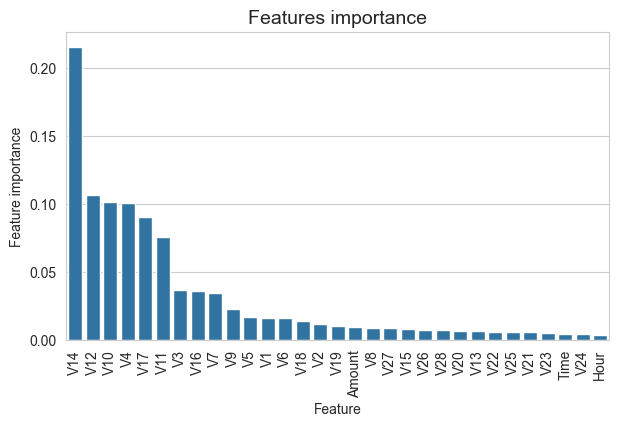

In [67]:
tmp = pd.DataFrame({'Feature': features, 'Feature importance': clf.feature_importances_})
tmp = tmp.sort_values(by='Feature importance', ascending=False)

plt.figure(figsize = (7,4))
plt.title('Features importance',fontsize=14)

s = sns.barplot(x='Feature', y='Feature importance', data=tmp)
s.set_xticklabels(s.get_xticklabels(),rotation=90)
plt.show()   

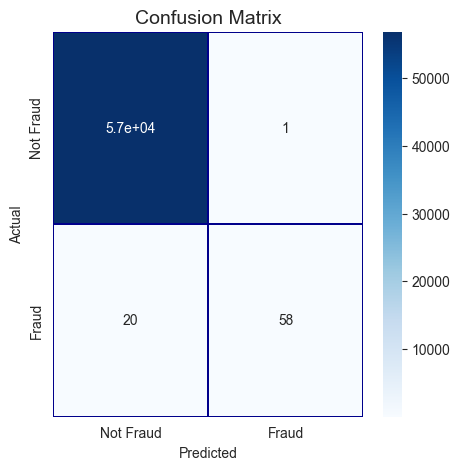

In [68]:
cm = pd.crosstab(val_df[target].values, preds, rownames=['Actual'], colnames=['Predicted'])
fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
sns.heatmap(cm, 
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues")
plt.title('Confusion Matrix', fontsize=14)
plt.show()

In [69]:
roc_auc_score(val_df[target].values, preds)

0.8717860819769968

In [70]:
average_precision_score(val_df[target].values, preds) 

0.7313376388638577

### XGBoost

In [71]:
# Prepare the train and valid datasets
dtrain = xgb.DMatrix(train_df[features], train_df[target].values)
dvalid = xgb.DMatrix(val_df[features], val_df[target].values)
dtest = xgb.DMatrix(test_df[features], test_df[target].values)

#What to monitor (in this case, **train** and **valid**)
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

# Set xgboost parameters
params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.039
params['silent'] = True
params['max_depth'] = 2
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'aucpr'
params['random_state'] = 42

In [72]:
model = xgb.train(params, 
                dtrain, 
                1000, 
                watchlist, 
                early_stopping_rounds=50, 
                maximize=True, 
                verbose_eval=50)

[0]	train-aucpr:0.16682	valid-aucpr:0.13247


/Users/yukunliu/Desktop/Repo/XGBoost/CreditCardFraudDetection/.fraud/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
/Users/yukunliu/Desktop/Repo/XGBoost/CreditCardFraudDetection/.fraud/lib/python3.11/site-packages/xgboost/callback.py:385: UserWarning: [23:09:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	train-aucpr:0.80802	valid-aucpr:0.74525
[100]	train-aucpr:0.83835	valid-aucpr:0.78616
[150]	train-aucpr:0.85441	valid-aucpr:0.79823
[200]	train-aucpr:0.86876	valid-aucpr:0.80465
[250]	train-aucpr:0.87970	valid-aucpr:0.81230
[300]	train-aucpr:0.88833	valid-aucpr:0.81390
[350]	train-aucpr:0.89825	valid-aucpr:0.81718
[400]	train-aucpr:0.90633	valid-aucpr:0.82003
[450]	train-aucpr:0.91337	valid-aucpr:0.82109
[500]	train-aucpr:0.92065	valid-aucpr:0.82160
[550]	train-aucpr:0.92722	valid-aucpr:0.82267
[600]	train-aucpr:0.93375	valid-aucpr:0.82427
[650]	train-aucpr:0.93972	valid-aucpr:0.82843
[700]	train-aucpr:0.94461	valid-aucpr:0.83008
[750]	train-aucpr:0.94991	valid-aucpr:0.83029
[766]	train-aucpr:0.95187	valid-aucpr:0.83028


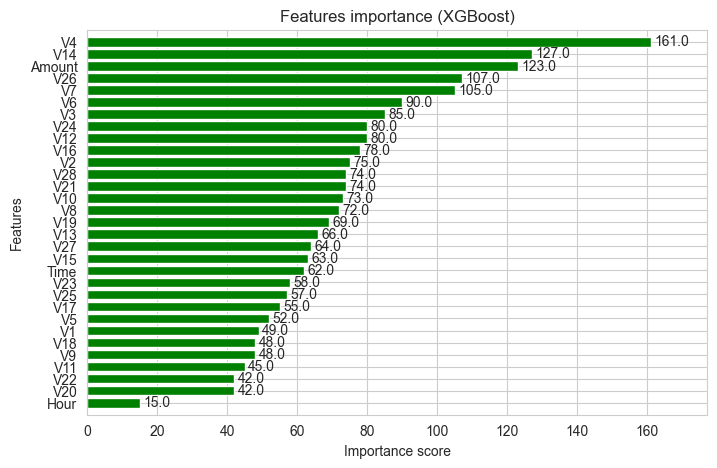

In [73]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
xgb.plot_importance(model, height=0.8, title="Features importance (XGBoost)", ax=ax, color="green") 
plt.show()

In [74]:
preds = model.predict(dtest)

In [75]:
roc_auc_score(test_df[target].values, preds)

0.9871230533575276

In [76]:
average_precision_score(test_df[target].values, preds) 

0.8868377273591203

### LightGBM

In [77]:
params = {
          'boosting_type': 'gbdt',
          'objective': 'binary',
          'metric':'auc',
          'learning_rate': 0.05,
          'num_leaves': 7,  # we should let it be smaller than 2^(max_depth)
          'max_depth': 4,  # -1 means no limit
          'min_child_samples': 100,  # Minimum number of data need in a child(min_data_in_leaf)
          'max_bin': 100,  # Number of bucketed bin for feature values
          'subsample': 0.9,  # Subsample ratio of the training instance.
          'subsample_freq': 1,  # frequence of subsample, <=0 means no enable
          'colsample_bytree': 0.7,  # Subsample ratio of columns when constructing each tree.
          'min_child_weight': 0,  # Minimum sum of instance weight(hessian) needed in a child(leaf)
          'min_split_gain': 0,  # lambda_l1, lambda_l2 and min_gain_to_split to regularization
          'nthread': 8,
          'verbose': 0,
          'scale_pos_weight':150, # because training data is extremely unbalanced 
         }

In [79]:
dtrain = lgb.Dataset(train_df[features].values, 
                     label=train_df[target].values,
                     feature_name=features)

dvalid = lgb.Dataset(val_df[features].values,
                     label=val_df[target].values,
                     feature_name=features)

In [85]:
evals_result = {}

model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(50),
        lgb.record_evaluation(evals_result)
    ]
)

Training until validation scores don't improve for 100 rounds
[50]	train's auc: 0.997593	valid's auc: 0.859336
[100]	train's auc: 0.998593	valid's auc: 0.860574
Early stopping, best iteration is:
[2]	train's auc: 0.971721	valid's auc: 0.938376


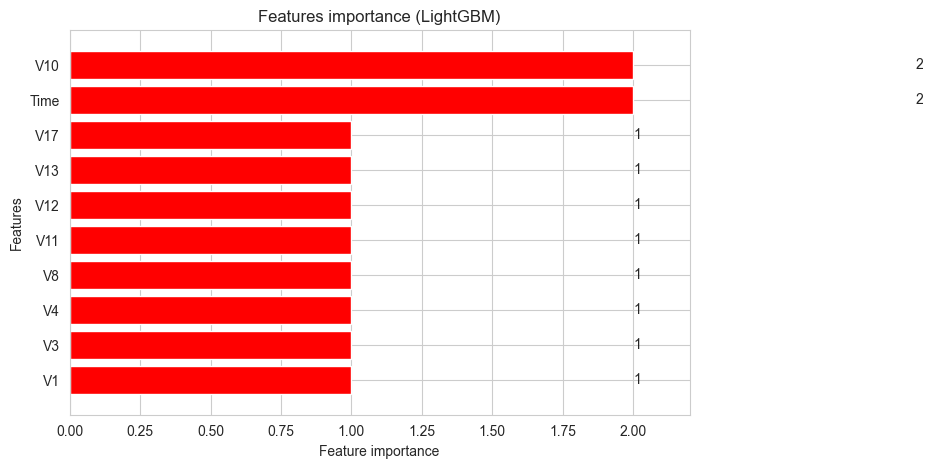

In [86]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
lgb.plot_importance(model, height=0.8, title="Features importance (LightGBM)", ax=ax,color="red") 
plt.show()

In [87]:
preds = model.predict(test_df[features])

In [88]:
roc_auc_score(test_df[target].values, preds)

0.9554074777772674

In [90]:
kf = KFold(n_splits = 5, random_state = 42, shuffle = True)

# Create arrays and dataframes to store results
oof_preds = np.zeros(train_df.shape[0])
test_preds = np.zeros(test_df.shape[0])
feature_importance_df = pd.DataFrame()
n_fold = 0
for train_idx, valid_idx in kf.split(train_df):
    train_x, train_y = train_df[features].iloc[train_idx],train_df[target].iloc[train_idx]
    valid_x, valid_y = train_df[features].iloc[valid_idx],train_df[target].iloc[valid_idx]
    
    evals_results = {}
    model =  LGBMClassifier(
                  nthread=-1,
                  n_estimators=2000,
                  learning_rate=0.01,
                  num_leaves=80,
                  colsample_bytree=0.98,
                  subsample=0.78,
                  reg_alpha=0.04,
                  reg_lambda=0.073,
                  subsample_for_bin=50,
                  boosting_type='gbdt',
                  is_unbalance=False,
                  min_split_gain=0.025,
                  min_child_weight=40,
                  min_child_samples=510,
                  objective='binary',
                  metric='auc',
                  silent=-1,
                  verbose=-1,
                  feval=None)
    model.fit(
        train_x,
        train_y,
        eval_set=[(train_x, train_y), (valid_x, valid_y)],
        eval_metric='auc',
        callbacks=[
            lgb.log_evaluation(50),
            lgb.early_stopping(50)
        ]
    )
    
    oof_preds[valid_idx] = model.predict_proba(valid_x, num_iteration=model.best_iteration_)[:, 1]
    test_preds += model.predict_proba(test_df[features], num_iteration=model.best_iteration_)[:, 1] / kf.n_splits
    
    fold_importance_df = pd.DataFrame()
    fold_importance_df["feature"] = features
    fold_importance_df["importance"] = clf.feature_importances_
    fold_importance_df["fold"] = n_fold + 1
    
    feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)
    print('Fold %2d AUC : %.6f' % (n_fold + 1, roc_auc_score(valid_y, oof_preds[valid_idx])))
    del model, train_x, train_y, valid_x, valid_y
    gc.collect()
    n_fold = n_fold + 1
train_auc_score = roc_auc_score(train_df[target], oof_preds)
print('Full AUC score %.6f' % train_auc_score)   

Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.978797	valid_1's auc: 0.96366
Early stopping, best iteration is:
[8]	training's auc: 0.963881	valid_1's auc: 0.970132
Fold  1 AUC : 0.970132
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.967222	valid_1's auc: 0.972878
[100]	training's auc: 0.976546	valid_1's auc: 0.984184
[150]	training's auc: 0.978454	valid_1's auc: 0.983759
Early stopping, best iteration is:
[124]	training's auc: 0.978198	valid_1's auc: 0.984926
Fold  2 AUC : 0.984926
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.966976	valid_1's auc: 0.965978
Early stopping, best iteration is:
[19]	training's auc: 0.971008	valid_1's auc: 0.973402
Fold  3 AUC : 0.973402
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.979045	valid_1's auc: 0.975241
[100]	training's auc: 0.981039	valid_1's auc: 0.982556
[150]	training's auc: 0.981982	valid_1's